# Bài 3 — Luật kết hợp

## Phần: Airbnb

Khai phá các tổ hợp tiện nghi (`amenities`) thường xuất hiện cùng nhau
trong listing Airbnb.

## 1. Mục tiêu và phương pháp

- 30.218 giao dịch (listing) × 182 item (tiện nghi), trung bình 27,8
  item/giao dịch — dữ liệu dày đặc, nên bắt đầu min_support cao rồi hạ dần.
- Loại trước các item support quá cao (gần như listing nào cũng có), vì
  luật chứa chúng thường tầm thường.
- So sánh ≥ 2 ngưỡng min_support để thấy số luật bùng nổ thế nào.
- So sánh Apriori vs FP-Growth về thời gian chạy.
- Lọc luật cuối bằng lift > 1.2 và loại luật dư thừa.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

DATA_PATH = Path('../data/processed/airbnb/airbnb_association.csv')
COMMON_THRESHOLD = 0.85
MIN_LIFT = 1.2
MIN_CONFIDENCE = 0.6
sns.set_theme(style='whitegrid')

In [5]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Số item/giao dịch trung bình:', round(df.sum(axis=1).mean(), 2))
display(df.head())

Shape: (30218, 182)
Số item/giao dịch trung bình: 27.8


,AC - split type ductless system,Air conditioning,BBQ grill,Baby bath,Baby safety gates,Babysitter recommendations,Backyard,Baking sheet,Bar,Barbecue utensils,...,Toaster,Trash compactor,Washer,Washer – In building,Washer – In unit,Waterfront,Wifi,Window AC unit,Window guards,Wine glasses
0,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,False,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True


### 2. Giải trình đơn vị giao dịch / rời rạc hóa

Mỗi dòng = 1 giao dịch = 1 listing; mỗi cột = 1 item = 1 tiện nghi trong
danh sách `amenities` gốc. Giá trị 1 nếu listing có tiện nghi, 0 nếu không.
Dữ liệu đã nhị phân sẵn từ Bài 1, không cần rời rạc hóa thêm.

In [6]:
item_support = df.mean().sort_values(ascending=False)

print('--- Top 15 item phổ biến nhất ---')
display(item_support.head(15).to_frame('support'))

print('--- 10 item hiếm nhất ---')
display(item_support.tail(10).to_frame('support'))

--- Top 15 item phổ biến nhất ---


,support
Wifi,0.935701
Smoke alarm,0.929347
Kitchen,0.863029
Carbon monoxide alarm,0.826395
Essentials,0.730227
Hangers,0.722318
Hot water,0.714905
Air conditioning,0.707294
Heating,0.653617
Hair dryer,0.651367


--- 10 item hiếm nhất ---


,support
Paid parking lot off premises,0.006585
Outdoor playground,0.006089
Children's playroom,0.005758
"Exercise equipment: free weights, yoga mat",0.005725
Shared beach access,0.005593
Stainless steel stove,0.005427
EV charger,0.005262
Resort access,0.005262
Exercise equipment: yoga mat,0.005162
Fireplace guards,0.005030


In [7]:
COMMON_THRESHOLD = 0.85   # hạ từ 0.95 xuống 0.85 vì item cao nhất chỉ đạt ~0.94

common_items = item_support[item_support > COMMON_THRESHOLD].index.tolist()
print(f'Loại {len(common_items)} item support > {COMMON_THRESHOLD}:')
print(common_items)

df_mining = df.drop(columns=common_items)
print('Shape sau khi loại:', df_mining.shape)

Loại 3 item support > 0.85:
['Wifi', 'Smoke alarm', 'Kitchen']
Shape sau khi loại: (30218, 179)


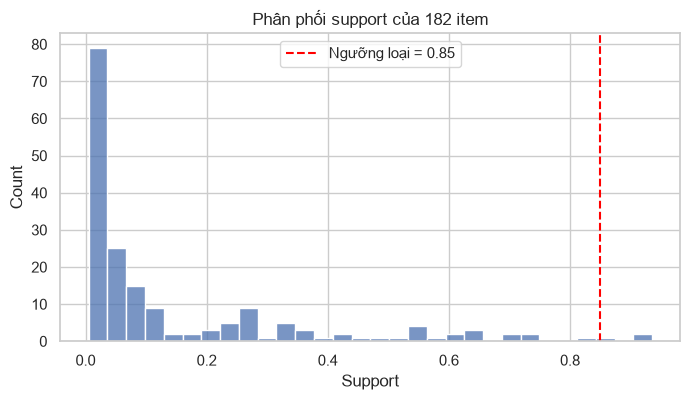

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(item_support, bins=30)
plt.title('Phân phối support của 182 item')
plt.xlabel('Support')
plt.axvline(COMMON_THRESHOLD, color='red', linestyle='--', label=f'Ngưỡng loại = {COMMON_THRESHOLD}')
plt.legend()
plt.show()

In [9]:
common_items = item_support[item_support > COMMON_THRESHOLD].index.tolist()
print(f'Loại {len(common_items)} item support > {COMMON_THRESHOLD}:')
print(common_items)

df_mining = df.drop(columns=common_items)
print('Shape sau khi loại:', df_mining.shape)

Loại 3 item support > 0.85:
['Wifi', 'Smoke alarm', 'Kitchen']
Shape sau khi loại: (30218, 179)


In [10]:
tuning_rows = []
for min_sup in [0.20, 0.15, 0.10, 0.08]:  
    start = time.time()
    fi = fpgrowth(df_mining, min_support=min_sup, use_colnames=True)
    elapsed = time.time() - start
    tuning_rows.append({'min_support': min_sup, 'n_itemsets': len(fi), 'time_sec': round(elapsed, 2)})
    print(min_sup, 'xong, mất', round(elapsed, 2), 's')  

tuning_results = pd.DataFrame(tuning_rows)
display(tuning_results)

0.2 xong, mất 2.65 s
0.15 xong, mất 7.82 s
0.1 xong, mất 35.88 s
0.08 xong, mất 99.95 s


,min_support,n_itemsets,time_sec
0,0.20,24941,2.65
1,0.15,126142,7.82
2,0.10,1219391,35.88
3,0.08,4195080,99.95


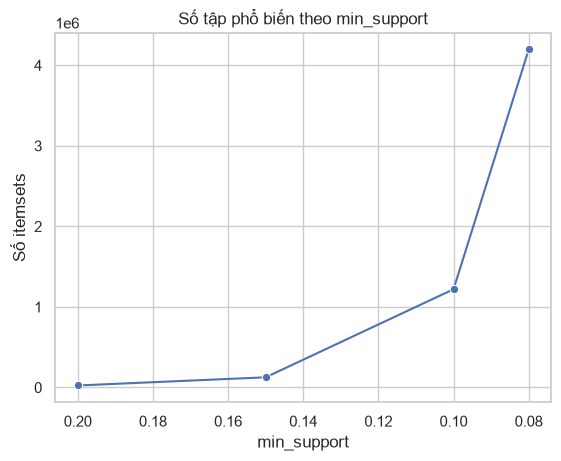

In [11]:
ax = sns.lineplot(data=tuning_results, x='min_support', y='n_itemsets', marker='o')
ax.set(title='Số tập phổ biến theo min_support', ylabel='Số itemsets')
plt.gca().invert_xaxis()
plt.show()

### 3. Chọn min_support cuối cùng

Nhìn bảng và biểu đồ ở trên, chọn ngưỡng cân bằng giữa "đủ luật để phân
tích" và "chưa bùng nổ quá nhiều luật vô nghĩa". Ghi rõ ngưỡng đã chọn và
lý do dựa trên số liệu thực tế.

In [12]:
MIN_SUPPORT_FINAL = 0.15

print('Chọn min_support =', MIN_SUPPORT_FINAL)

Chọn min_support = 0.15


In [13]:
ALGO_COMPARE_SUPPORT = 0.20  # dùng ngưỡng nhẹ hơn để so sánh 2 thuật toán an toàn

start = time.time()
fi_apriori = apriori(df_mining, min_support=ALGO_COMPARE_SUPPORT, use_colnames=True)
time_apriori = time.time() - start
print('Apriori xong, mất', round(time_apriori, 2), 's')

start = time.time()
fi_fpgrowth_compare = fpgrowth(df_mining, min_support=ALGO_COMPARE_SUPPORT, use_colnames=True)
time_fpgrowth_compare = time.time() - start
print('FP-Growth xong, mất', round(time_fpgrowth_compare, 2), 's')

algo_compare = pd.DataFrame([
    {'algorithm': 'Apriori', 'n_itemsets': len(fi_apriori), 'time_sec': round(time_apriori, 3)},
    {'algorithm': 'FP-Growth', 'n_itemsets': len(fi_fpgrowth_compare), 'time_sec': round(time_fpgrowth_compare, 3)},
])
display(algo_compare)

Apriori xong, mất 2.98 s
FP-Growth xong, mất 2.36 s


,algorithm,n_itemsets,time_sec
0,Apriori,24941,2.979
1,FP-Growth,24941,2.358


In [14]:
ALGO_COMPARE_LOW = 0.15

start = time.time()
fi_apriori_low = apriori(df_mining, min_support=ALGO_COMPARE_LOW, use_colnames=True)
time_apriori_low = time.time() - start
print('Apriori (0.15) xong, mất', round(time_apriori_low, 2), 's')

start = time.time()
fi_fpgrowth_low = fpgrowth(df_mining, min_support=ALGO_COMPARE_LOW, use_colnames=True)
time_fpgrowth_low = time.time() - start
print('FP-Growth (0.15) xong, mất', round(time_fpgrowth_low, 2), 's')

Apriori (0.15) xong, mất 24.49 s
FP-Growth (0.15) xong, mất 14.48 s


In [15]:
speedup_020 = time_apriori / time_fpgrowth_compare
speedup_015 = time_apriori_low / time_fpgrowth_low

print(f'Ở min_support=0.20: Apriori/FP-Growth = {speedup_020:.2f} '
      f'({"FP-Growth nhanh hơn" if speedup_020 > 1 else "Apriori nhanh hơn"})')
print(f'Ở min_support=0.15: Apriori/FP-Growth = {speedup_015:.2f} '
      f'({"FP-Growth nhanh hơn" if speedup_015 > 1 else "Apriori nhanh hơn"} '
      f'khoảng {speedup_015:.1f} lần)')

Ở min_support=0.20: Apriori/FP-Growth = 1.26 (FP-Growth nhanh hơn)
Ở min_support=0.15: Apriori/FP-Growth = 1.69 (FP-Growth nhanh hơn khoảng 1.7 lần)


In [16]:
rules = association_rules(fi_fpgrowth_low, metric='confidence', min_threshold=MIN_CONFIDENCE)
print('Số luật trước lọc:', len(rules))
display(rules.head())

Số luật trước lọc: 5878572


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Carbon monoxide alarm}),frozenset({Essentials}),0.826395,0.730227,0.619333,0.749439,1.026310,1.0,0.015877,1.076677,0.147666,0.660770,0.071217,0.798788
1,frozenset({Essentials}),frozenset({Carbon monoxide alarm}),0.730227,0.826395,0.619333,0.848137,1.026310,1.0,0.015877,1.143172,0.095027,0.660770,0.125241,0.798788
2,frozenset({Carbon monoxide alarm}),frozenset({Hangers}),0.826395,0.722318,0.627606,0.759451,1.051408,1.0,0.030686,1.154366,0.281641,0.681361,0.133724,0.814164
3,frozenset({Hangers}),frozenset({Carbon monoxide alarm}),0.722318,0.826395,0.627606,0.868878,1.051408,1.0,0.030686,1.323997,0.176080,0.681361,0.244711,0.814164
4,frozenset({Essentials}),frozenset({Hangers}),0.730227,0.722318,0.622179,0.852035,1.179584,1.0,0.094723,1.876672,0.564340,0.749283,0.467142,0.856700


In [17]:
MIN_CONFIDENCE_STRICT = 0.85  # nâng từ 0.6 lên 0.85 để giảm bùng nổ

rules = association_rules(fi_fpgrowth_low, metric='confidence', min_threshold=MIN_CONFIDENCE_STRICT)
print('Số luật trước lọc (confidence >= 0.85):', len(rules))

Số luật trước lọc (confidence >= 0.85): 1371037


In [18]:
MIN_SUPPORT_FINAL = 0.20   # đổi lại từ 0.15 -> 0.20 để sinh luật khả thi

rules = association_rules(fi_fpgrowth_compare, metric='confidence', min_threshold=MIN_CONFIDENCE)
print('Số luật trước lọc:', len(rules))
display(rules.head())

Số luật trước lọc: 711995


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Carbon monoxide alarm}),frozenset({Essentials}),0.826395,0.730227,0.619333,0.749439,1.026310,1.0,0.015877,1.076677,0.147666,0.660770,0.071217,0.798788
1,frozenset({Essentials}),frozenset({Carbon monoxide alarm}),0.730227,0.826395,0.619333,0.848137,1.026310,1.0,0.015877,1.143172,0.095027,0.660770,0.125241,0.798788
2,frozenset({Carbon monoxide alarm}),frozenset({Hangers}),0.826395,0.722318,0.627606,0.759451,1.051408,1.0,0.030686,1.154366,0.281641,0.681361,0.133724,0.814164
3,frozenset({Hangers}),frozenset({Carbon monoxide alarm}),0.722318,0.826395,0.627606,0.868878,1.051408,1.0,0.030686,1.323997,0.176080,0.681361,0.244711,0.814164
4,frozenset({Essentials}),frozenset({Hangers}),0.730227,0.722318,0.622179,0.852035,1.179584,1.0,0.094723,1.876672,0.564340,0.749283,0.467142,0.856700


In [19]:
rules_filtered = rules[rules['lift'] > MIN_LIFT].copy()
print('Sau lọc lift > {}: {}'.format(MIN_LIFT, len(rules_filtered)))

Sau lọc lift > 1.2: 694073


In [20]:
# Sắp xếp theo lift giảm dần, lấy top 200 trước để giảm tải cho bước dedup
top_by_lift = rules_filtered.sort_values('lift', ascending=False).head(200).copy()
print('Đã lấy top 200 luật theo lift, chuẩn bị dedup...')

top_by_lift['antecedent_len'] = top_by_lift['antecedents'].apply(len)
top_by_lift = top_by_lift.sort_values(['antecedent_len', 'lift'], ascending=[True, False])
rules_dedup = top_by_lift.drop_duplicates(subset=['consequents', 'confidence'], keep='first')

print('Sau loại dư thừa:', len(rules_dedup))

Đã lấy top 200 luật theo lift, chuẩn bị dedup...
Sau loại dư thừa: 200


In [21]:
top_rules = rules_dedup.sort_values('lift', ascending=False).head(10)

display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
top_rules_display = top_rules[display_cols].copy()
top_rules_display['antecedents'] = top_rules_display['antecedents'].apply(lambda s: ', '.join(sorted(s)))
top_rules_display['consequents'] = top_rules_display['consequents'].apply(lambda s: ', '.join(sorted(s)))

display(top_rules_display.style.format({'support': '{:.4f}', 'confidence': '{:.4f}', 'lift': '{:.3f}'}))

,antecedents,consequents,support,confidence,lift
665181,"Dishes and silverware, Essentials, Oven","Cooking basics, Hot water, Refrigerator, Stove",0.2017,0.7230,2.734
665140,"Cooking basics, Hot water, Refrigerator, Stove","Dishes and silverware, Essentials, Oven",0.2017,0.7627,2.734
665153,"Dishes and silverware, Essentials, Oven, Refrigerator","Cooking basics, Hot water, Stove",0.2017,0.7447,2.716
665175,"Cooking basics, Hot water, Stove","Dishes and silverware, Essentials, Oven, Refrigerator",0.2017,0.7355,2.716
667637,"Refrigerator, Stove","Dishes and silverware, Heating, Oven",0.2038,0.6661,2.712
667636,"Dishes and silverware, Heating, Oven","Refrigerator, Stove",0.2038,0.8299,2.712
681160,"Dishes and silverware, Freezer, Hot water","Cooking basics, Wine glasses",0.2014,0.6708,2.707
681164,"Cooking basics, Wine glasses","Dishes and silverware, Freezer, Hot water",0.2014,0.8129,2.707
681167,"Cooking basics, Freezer","Dishes and silverware, Hot water, Wine glasses",0.2014,0.6808,2.705
681157,"Dishes and silverware, Hot water, Wine glasses","Cooking basics, Freezer",0.2014,0.8003,2.705


## 4. Khung nhận xét cho báo cáo (Phần — Airbnb)

1. Item nào bị loại và vì sao (Cell 8): loại Wifi, Smoke alarm, Kitchen
   (support > 0.85) vì luật chứa chúng thường tầm thường.
2. Bảng/biểu đồ min_support — lý do chọn ngưỡng cuối (Cell 9-11).
3. Số liệu so sánh Apriori vs FP-Growth (Cell 13-14).
4. Diễn giải 5–10 luật nổi bật (Cell 18): support/confidence/lift nói gì,
   ưu tiên cặp tiện nghi ít phổ biến hơn.
5. Chỉ mức kỹ thuật, không diễn giải nghiệp vụ sâu (để dành đồ án).